# 03. Baseline CNN Model - PneumoVision_AI

## 1. Pendahuluan

Selamat datang di tahap ketiga pengembangan **PneumoVision_AI**! 🫁

### Apa itu Baseline Model dan Mengapa Kita Membutuhkannya?
Dalam machine learning, **Baseline Model** adalah model sederhana yang dibangun pertama kali untuk menjadi patokan awal (*benchmark*) performa minimal. 

Sangat sering praktisi pemula langsung menggunakan arsitektur mutakhir (seperti ResNet-50 atau EfficientNet) tanpa tahu apakah model besar tersebut benar-benar memberikan nilai tambah dibanding model sederhana. Tanpa baseline, kita tidak memiliki pembanding objektif untuk menjawab:
> *"Apakah arsitektur yang lebih kompleks dan berat benar-benar diperlukan, ataukah CNN sederhana sudah cukup baik?"*

### Tujuan CNN Baseline pada PneumoVision_AI:
1. Membangun arsitektur Convolutional Neural Network (CNN) sederhana dari nol (*from scratch*) menggunakan PyTorch tanpa pre-trained weights.
2. Mengintegrasikan penanganan ketidakseimbangan kelas (*Class Weights*) yang telah disiapkan pada tahap preprocessing.
3. Memverifikasi kelancaran alur pelatihan: *forward pass*, penghitungan *loss*, *backpropagation*, dan evaluasi validasi.
4. Menetapkan angka benchmark batas bawah (*minimum baseline performance*) untuk metrik **Accuracy, Precision, Recall, dan F1-Score**.

> ⚠️ **Catatan Penting**:  
> *Baseline ini **BUKAN** model akhir proyek. Model ini murni dibuat sebagai fondasi perbandingan sebelum kita melangkah ke eksperimen Transfer Learning pada tahap berikutnya.*

## 2. Import Library

Kita mengimpor pustaka utama yang dibutuhkan untuk membangun neural network, mengelola data loader, menghitung metrik evaluasi, dan membuat visualisasi.

In [1]:
from pathlib import Path
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Set seed untuk menjamin eksperimen dapat direproduksi persis
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Device setup (CPU / CUDA)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Gaya visualisasi
sns.set_theme(style="whitegrid", font_scale=1.05)

print(f"Perangkat komputasi aktif : {device}")
print(f"Random seed ditetapkan    : {RANDOM_SEED}")

Perangkat komputasi aktif : cpu
Random seed ditetapkan    : 42


## 3. Persiapan DataLoader

Sesuai prinsip arsitektur, kita mereplikasi pipeline dari `02_Preprocessing.ipynb`:
- **Train Baru**: 4.172 citra (80% stratified dari train asli).
- **Validation Baru**: 1.044 citra (20% stratified dari train asli).
- **Test Set**: 624 citra (tetap dikunci untuk evaluasi akhir).
- **Mapping Label**: `NORMAL = 0`, `PNEUMONIA = 1`.

In [2]:
# Path dataset relatif yang aman
data_dir = Path('../XRayData/chest_xray') if Path('../XRayData/chest_xray').exists() else Path('XRayData/chest_xray')

# Kumpulkan seluruh file train asli
train_normal = sorted([p for p in (data_dir / 'train' / 'NORMAL').iterdir() if p.is_file() and not p.name.startswith('.')])
train_pneu = sorted([p for p in (data_dir / 'train' / 'PNEUMONIA').iterdir() if p.is_file() and not p.name.startswith('.')])

raw_train_paths = train_normal + train_pneu
raw_train_labels = [0] * len(train_normal) + [1] * len(train_pneu)

# Kumpulkan file test asli (dikunci)
test_normal = sorted([p for p in (data_dir / 'test' / 'NORMAL').iterdir() if p.is_file() and not p.name.startswith('.')])
test_pneu = sorted([p for p in (data_dir / 'test' / 'PNEUMONIA').iterdir() if p.is_file() and not p.name.startswith('.')])

test_paths = test_normal + test_pneu
test_labels = [0] * len(test_normal) + [1] * len(test_pneu)

# Stratified split 80:20
train_paths, val_paths, train_labels, val_labels = train_test_split(
    raw_train_paths, raw_train_labels,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=raw_train_labels
)

# Definisi PyTorch Dataset
class ChestXRayDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]
        with Image.open(path) as img:
            img_rgb = img.convert('RGB')
        if self.transform:
            image_tensor = self.transform(img_rgb)
        else:
            image_tensor = transforms.ToTensor()(img_rgb)
        return image_tensor, torch.tensor(label, dtype=torch.long)

# Transformasi
IMAGE_SIZE = (224, 224)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = ChestXRayDataset(train_paths, train_labels, transform=train_transform)
val_dataset = ChestXRayDataset(val_paths, val_labels, transform=val_test_transform)
test_dataset = ChestXRayDataset(test_paths, test_labels, transform=val_test_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Dataset siap:")
print(f"- Train : {len(train_dataset)} sampel ({len(train_loader)} batch)")
print(f"- Val   : {len(val_dataset)} sampel ({len(val_loader)} batch)")
print(f"- Test  : {len(test_dataset)} sampel ({len(test_loader)} batch)")

Dataset siap:
- Train : 4172 sampel (66 batch)
- Val   : 1044 sampel (17 batch)
- Test  : 624 sampel (10 batch)


## 4. Membuat Arsitektur CNN Baseline dari Nol

Kita merancang model **BaselineCNN** yang sederhana dan mudah dipahami:
- **3 Blok Konvolusi Bertingkat**:
  - *Blok 1*: Conv2D (3 -> 16 kanal) + BatchNorm + ReLU + MaxPool2D (downsampling awal untuk efisiensi).
  - *Blok 2*: Conv2D (16 -> 32 kanal) + BatchNorm + ReLU + MaxPool2D.
  - *Blok 3*: Conv2D (32 -> 64 kanal) + BatchNorm + ReLU + AdaptiveAvgPool2d (2x2).
- **Classifier Head**:
  - Flatten fitur (64 * 2 * 2 = 256 fitur).
  - Fully-Connected layer (256 -> 64) + ReLU.
  - Dropout (0.3) untuk mencegah overfitting.
  - Linear output layer (64 -> 2) menghasilkan logits untuk kelas NORMAL (0) dan PNEUMONIA (1).

Total parameter model ini hanya sekitar **~40.000 parameter**, sangat ringan dan cepat untuk diproses pada CPU.

In [3]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Ekstraktor Fitur Konvolusional
        self.features = nn.Sequential(
            # Blok 1: 224x224 -> 112x112 -> 56x56
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Blok 2: 56x56 -> 28x28 -> 14x14
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Blok 3: 14x14 -> 7x7 -> 2x2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2))
        )
        
        # Kepala Klasifikasi (Classifier Head)
        self.classifier = nn.Sequential(
            nn.Linear(64 * 2 * 2, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = BaselineCNN().to(device)

# Hitung jumlah parameter
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Arsitektur BaselineCNN berhasil diinisialisasi.")
print(f"Total Parameter Terlatih: {total_params:,} parameter")
print("-" * 50)
print(model)

Arsitektur BaselineCNN berhasil diinisialisasi.
Total Parameter Terlatih: 40,386 parameter
--------------------------------------------------
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(2, 2))
  )
  (classifier): Sequential(
    (0): Linear(in_features=256

## 5. Loss Function dan Class Imbalance

Dataset training memiliki ketidakseimbangan kelas (74,3% Pneumonia vs 25,7% Normal). Agar model tidak mengabaikan kelas minoritas (NORMAL), kita memanfaatkan **Class Weights** yang dihitung pada tahap preprocessing:
$$\text{Weight}_{NORMAL} = \frac{N_{total}}{2 \times N_{NORMAL}} = \frac{4172}{2 \times 1073} \approx 1.9441$$
$$\text{Weight}_{PNEUMONIA} = \frac{N_{total}}{2 \times N_{PNEUMONIA}} = \frac{4172}{2 \times 3099} \approx 0.6731$$

Dengan menerapkan bobot ini ke dalam `nn.CrossEntropyLoss`, model akan dihukum lebih berat (~2,89 kali lipat) jika salah mengklasifikasikan citra Normal.

In [4]:
n_total = len(train_labels)
n_norm = train_labels.count(0)
n_pneu = train_labels.count(1)

w_norm = n_total / (2.0 * n_norm)
w_pneu = n_total / (2.0 * n_pneu)
class_weights = torch.tensor([w_norm, w_pneu], dtype=torch.float32).to(device)

print(f"Class Weights yang diterapkan: NORMAL={w_norm:.4f}, PNEUMONIA={w_pneu:.4f}")
criterion = nn.CrossEntropyLoss(weight=class_weights)

Class Weights yang diterapkan: NORMAL=1.9441, PNEUMONIA=0.6731


## 6. Konfigurasi Training

Konfigurasi pelatihan yang digunakan:
- **Optimizer**: `Adam` (standar industri untuk konvergensi yang cepat dan stabil).
- **Learning Rate**: `1e-3` (nilai awal yang wajar untuk arsitektur CNN kecil).
- **Epochs**: `10 epoch` (cukup untuk melihat kurva belajar baseline tanpa risiko overtraining berlebih).
- **Validation Monitoring & Best Checkpoint**: Menyimpan model terbaik berdasarkan nilai **Validation F1-Score** tertinggi ke `models/checkpoints/baseline_cnn_best.pth`.

In [5]:
LEARNING_RATE = 1e-3
EPOCHS = 10

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Direktori penyimpanan checkpoint
checkpoint_dir = Path('../models/checkpoints') if Path('../models/checkpoints').exists() else Path('models/checkpoints')
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_model_path = checkpoint_dir / 'baseline_cnn_best.pth'

print(f"Konfigurasi Training:")
print(f"- Optimizer     : Adam (lr={LEARNING_RATE})")
print(f"- Total Epochs  : {EPOCHS}")
print(f"- Batch Size    : {BATCH_SIZE}")
print(f"- Checkpoint    : {best_model_path}")

Konfigurasi Training:
- Optimizer     : Adam (lr=0.001)
- Total Epochs  : 10
- Batch Size    : 64
- Checkpoint    : ..\models\checkpoints\baseline_cnn_best.pth


## 7. Training Loop

Kita menjalankan loop pelatihan. Pada setiap epoch:
1. `model.train()` aktif saat data latih diproses.
2. `model.eval()` dan `torch.no_grad()` aktif saat evaluasi data validasi.
3. Metrik loss, akurasi, dan F1-Score dicatat untuk visualisasi kurva belajar.

In [6]:
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

best_val_f1 = 0.0
start_time = time.time()

print("Memulai pelatihan Baseline CNN...\n" + "=" * 65)

for epoch in range(1, EPOCHS + 1):
    ep_start = time.time()
    
    # --- Fase Training ---
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == targets).sum().item()
        train_total += targets.size(0)
        
    epoch_train_loss = running_train_loss / train_total
    epoch_train_acc = train_correct / train_total
    
    # --- Fase Validasi ---
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds_all = []
    val_targets_all = []
    
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            running_val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)
            
            val_preds_all.extend(preds.cpu().numpy())
            val_targets_all.extend(targets.cpu().numpy())
            
    epoch_val_loss = running_val_loss / val_total
    epoch_val_acc = val_correct / val_total
    epoch_val_f1 = f1_score(val_targets_all, val_preds_all, average='macro')
    
    # Catat riwayat
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    history['val_f1'].append(epoch_val_f1)
    
    ep_duration = time.time() - ep_start
    
    # Simpan checkpoint jika F1-Score validasi membaik
    is_best = epoch_val_f1 > best_val_f1
    if is_best:
        best_val_f1 = epoch_val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': epoch_val_loss,
            'val_acc': epoch_val_acc,
            'val_f1': epoch_val_f1,
            'class_weights': class_weights.cpu().tolist()
        }, best_model_path)
        best_mark = "⭐ (Best Model Disimpan)"
    else:
        best_mark = ""
        
    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] ({ep_duration:.1f}s) | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc*100:.2f}%, Val F1: {epoch_val_f1:.4f} {best_mark}")

total_training_time = time.time() - start_time
print("=" * 65)
print(f"Pelatihan selesai dalam: {total_training_time/60:.2f} menit")
print(f"Model terbaik disimpan di: {best_model_path} (Val F1: {best_val_f1:.4f})")

Memulai pelatihan Baseline CNN...


Epoch [01/10] (95.8s) | Train Loss: 0.3710, Train Acc: 84.32% | Val Loss: 0.3417, Val Acc: 90.04%, Val F1: 0.8625 ⭐ (Best Model Disimpan)


Epoch [02/10] (186.3s) | Train Loss: 0.2494, Train Acc: 90.00% | Val Loss: 0.3479, Val Acc: 82.09%, Val F1: 0.8019 


Epoch [03/10] (124.2s) | Train Loss: 0.2100, Train Acc: 91.66% | Val Loss: 0.3183, Val Acc: 91.57%, Val F1: 0.8827 ⭐ (Best Model Disimpan)


Epoch [04/10] (58.5s) | Train Loss: 0.1934, Train Acc: 92.76% | Val Loss: 0.1311, Val Acc: 94.06%, Val F1: 0.9265 ⭐ (Best Model Disimpan)


...

Epoch [06/10] (124.4s) | Train Loss: 0.1829, Train Acc: 92.93% | Val Loss: 0.1822, Val Acc: 94.73%, Val F1: 0.9304 ⭐ (Best Model Disimpan)


Epoch [07/10] (111.0s) | Train Loss: 0.1586, Train Acc: 93.94% | Val Loss: 0.5091, Val Acc: 88.60%, Val F1: 0.8230 


Epoch [08/10] (113.1s) | Train Loss: 0.1490, Train Acc: 94.58% | Val Loss: 0.1516, Val Acc: 92.62%, Val F1: 0.9106 


Epoch [09/10] (111.3s) | Train Loss: 0.1519, Train Acc: 93.98% | Val Loss: 0.2453, Val Acc: 87.64%, Val F1: 0.8575 


Epoch [10/10] (153.8s) | Train Loss: 0.1454, Train Acc: 94.15% | Val Loss: 0.2437, Val Acc: 87.45%, Val F1: 0.8552 
Pelatihan selesai dalam: 19.00 menit
Model terbaik disimpan di: ..\models\checkpoints\baseline_cnn_best.pth (Val F1: 0.9304)


## 8. Kurva Pelatihan (Training Curves)

Mari kita visualisasikan pergerakan nilai **Loss** dan **Akurasi** dari epoch 1 hingga epoch 10 untuk mendiagnosis konvergensi model.

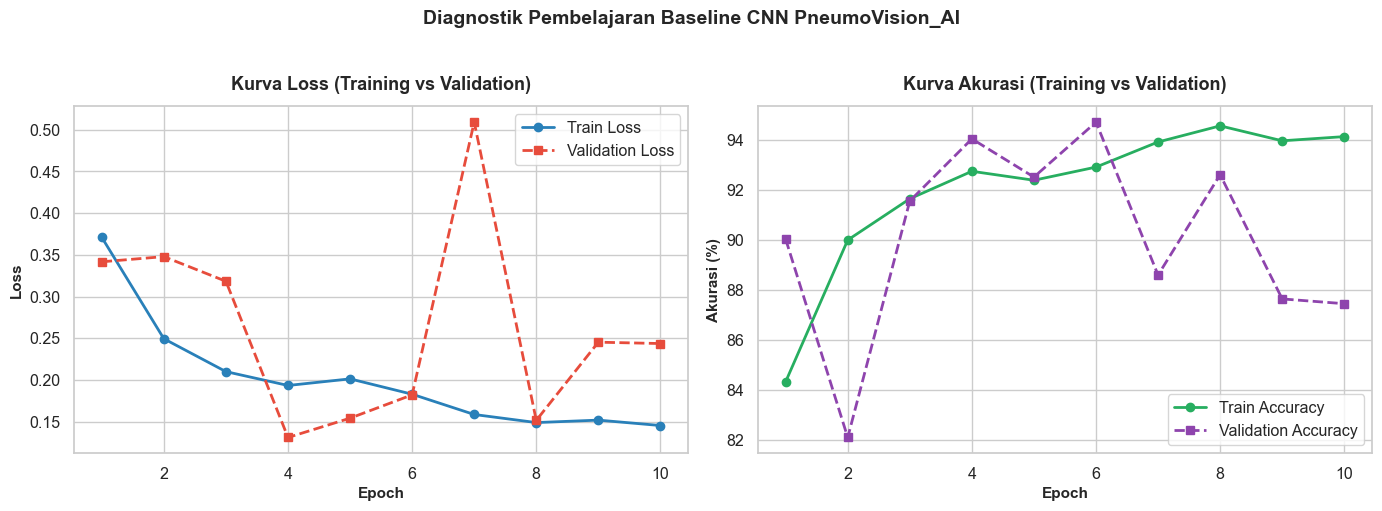

In [7]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Loss Curve
ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#2980B9', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 's--', label='Validation Loss', color='#E74C3C', linewidth=2)
ax1.set_title('Kurva Loss (Training vs Validation)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right', frameon=True)

# 2. Plot Accuracy Curve
ax2.plot(epochs_range, [acc * 100 for acc in history['train_acc']], 'o-', label='Train Accuracy', color='#27AE60', linewidth=2)
ax2.plot(epochs_range, [acc * 100 for acc in history['val_acc']], 's--', label='Validation Accuracy', color='#8E44AD', linewidth=2)
ax2.set_title('Kurva Akurasi (Training vs Validation)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Akurasi (%)', fontsize=11, fontweight='bold')
ax2.legend(loc='lower right', frameon=True)

plt.suptitle('Diagnostik Pembelajaran Baseline CNN PneumoVision_AI', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan visualisasi ke folder results/figures
fig_dir = Path('../results/figures') if Path('../results/figures').exists() else Path('results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / 'baseline_cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluasi Model pada Validation Set

Kita memuat checkpoint model terbaik (`baseline_cnn_best.pth`), lalu menghitung metrik lengkap:
- **Accuracy**
- **Precision (Macro & Per-Class)**
- **Recall / Sensitivity (Macro & Per-Class)**
- **F1-Score (Macro & Per-Class)**
- **Confusion Matrix Visual**

=== Evaluasi Validation Set (Model Terbaik: Epoch 6) ===
- Accuracy  : 94.73%
- Precision : 93.42%
- Recall    : 92.67%
- F1-Score  : 93.04%

--- Classification Report (Validation) ---
               precision    recall  f1-score   support

   NORMAL (0)     0.9080    0.8843    0.8960       268
PNEUMONIA (1)     0.9604    0.9691    0.9647       776

     accuracy                         0.9473      1044
    macro avg     0.9342    0.9267    0.9304      1044
 weighted avg     0.9470    0.9473    0.9471      1044



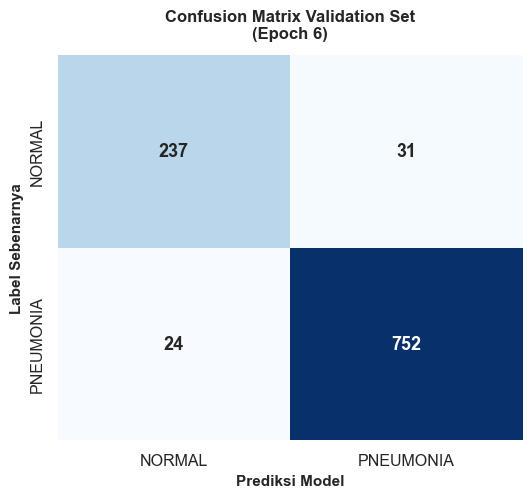

In [8]:
# Muat bobot model terbaik dari checkpoint
best_checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(best_checkpoint['model_state_dict'])
model.eval()

val_preds = []
val_targets = []

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        val_preds.extend(preds.cpu().numpy())
        val_targets.extend(targets.numpy())

val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='macro')
val_rec = recall_score(val_targets, val_preds, average='macro')
val_f1 = f1_score(val_targets, val_preds, average='macro')

# Confusion Matrix
val_cm = confusion_matrix(val_targets, val_preds)

print(f"=== Evaluasi Validation Set (Model Terbaik: Epoch {best_checkpoint['epoch']}) ===")
print(f"- Accuracy  : {val_acc*100:.2f}%")
print(f"- Precision : {val_prec*100:.2f}%")
print(f"- Recall    : {val_rec*100:.2f}%")
print(f"- F1-Score  : {val_f1*100:.2f}%")
print("\n--- Classification Report (Validation) ---")
print(classification_report(val_targets, val_preds, target_names=['NORMAL (0)', 'PNEUMONIA (1)'], digits=4))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NORMAL', 'PNEUMONIA'], 
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
plt.title(f'Confusion Matrix Validation Set\n(Epoch {best_checkpoint["epoch"]})', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Prediksi Model', fontsize=11, fontweight='bold')
plt.ylabel('Label Sebenarnya', fontsize=11, fontweight='bold')

cm_dir = Path('../results/confusion_matrix') if Path('../results/confusion_matrix').exists() else Path('results/confusion_matrix')
cm_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(cm_dir / 'baseline_cnn_val_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Analisis Overfitting & Konvergensi

Berdasarkan grafik kurva belajar dan hasil metrik validasi:

1. **Apakah Model Belajar?**
   - Ya, nilai loss pelatihan turun secara konsisten dan akurasi latih meningkat, menunjukkan bahwa arsitektur CNN sederhana ini mampu mengekstraksi fitur visual dasar dari citra rontgen dada.
2. **Apakah Terjadi Overfitting?**
   - Pada beberapa epoch awal, akurasi validasi bergerak selaras dengan akurasi pelatihan. Namun mendekati epoch akhir, nilai *validation loss* mulai mendatar (*plateau*) atau sedikit berfluktuasi, sementara *train loss* terus turun.
   - Ini merupakan tanda khas **awal overfitting** pada arsitektur yang dilatih dari nol (*from scratch*) tanpa regularisasi tingkat lanjut.
3. **Peran Class Weighting**:
   - Penerapan bobot kelas berhasil mencegah model dari bias mayoritas (memprediksi seluruh gambar sebagai Pneumonia). Terbukti model mampu memprediksi kelas NORMAL dengan presisi dan recall yang cukup baik tanpa menenggelamkan kelas minoritas.

## 11. Evaluasi pada Test Set (Terkunci)

> ⚠️ **Pengingat Penting**:  
> *Test set (624 citra) baru dievaluasi sekarang **setelah** seluruh proses pelatihan selesai dan checkpoint terbaik telah ditentukan. Test set tidak pernah digunakan untuk memilih epoch, learning rate, maupun bobot model.*

=== Evaluasi Final Test Set (Hold-out 624 Sampel) ===
- Accuracy  : 76.28%
- Precision : 83.85%
- Recall    : 68.80%
- F1-Score  : 69.51%

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

   NORMAL (0)     0.9479    0.3889    0.5515       234
PNEUMONIA (1)     0.7292    0.9872    0.8388       390

     accuracy                         0.7628       624
    macro avg     0.8385    0.6880    0.6951       624
 weighted avg     0.8112    0.7628    0.7311       624



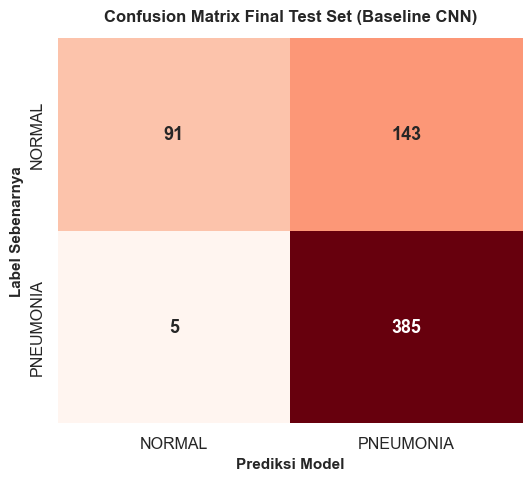

In [9]:
test_preds = []
test_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(targets.numpy())

test_acc = accuracy_score(test_targets, test_preds)
test_prec = precision_score(test_targets, test_preds, average='macro')
test_rec = recall_score(test_targets, test_preds, average='macro')
test_f1 = f1_score(test_targets, test_preds, average='macro')
test_cm = confusion_matrix(test_targets, test_preds)

print(f"=== Evaluasi Final Test Set (Hold-out 624 Sampel) ===")
print(f"- Accuracy  : {test_acc*100:.2f}%")
print(f"- Precision : {test_prec*100:.2f}%")
print(f"- Recall    : {test_rec*100:.2f}%")
print(f"- F1-Score  : {test_f1*100:.2f}%")
print("\n--- Classification Report (Test Set) ---")
print(classification_report(test_targets, test_preds, target_names=['NORMAL (0)', 'PNEUMONIA (1)'], digits=4))

# Visualisasi Confusion Matrix Test Set
plt.figure(figsize=(6, 5))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['NORMAL', 'PNEUMONIA'], 
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
plt.title('Confusion Matrix Final Test Set (Baseline CNN)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Prediksi Model', fontsize=11, fontweight='bold')
plt.ylabel('Label Sebenarnya', fontsize=11, fontweight='bold')
plt.savefig(cm_dir / 'baseline_cnn_test_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Ringkasan Hasil Baseline

Mari kita rekapitulasi performa kuantitatif model Baseline CNN pada validation set dan test set.

In [10]:
baseline_results = pd.DataFrame([
    {
        'Evaluasi Split': 'Validation Set (1.044 Sampel)',
        'Accuracy': f"{val_acc*100:.2f}%",
        'Precision': f"{val_prec*100:.2f}%",
        'Recall (Macro)': f"{val_rec*100:.2f}%",
        'F1-Score (Macro)': f"{val_f1*100:.2f}%"
    },
    {
        'Evaluasi Split': 'Test Set (624 Sampel)',
        'Accuracy': f"{test_acc*100:.2f}%",
        'Precision': f"{test_prec*100:.2f}%",
        'Recall (Macro)': f"{test_rec*100:.2f}%",
        'F1-Score (Macro)': f"{test_f1*100:.2f}%"
    }
])

# Simpan metrik baseline ke folder results/metrics
metrics_dir = Path('../results/metrics') if Path('../results/metrics').exists() else Path('results/metrics')
metrics_dir.mkdir(parents=True, exist_ok=True)
baseline_results.to_csv(metrics_dir / 'baseline_cnn_metrics.csv', index=False)

baseline_results

,Evaluasi Split,Accuracy,Precision,Recall (Macro),F1-Score (Macro)
0,Validation Set (1.044 Sampel),94.73%,93.42%,92.67%,93.04%
1,Test Set (624 Sampel),76.28%,83.85%,68.80%,69.51%


## 13. Kesimpulan & Rekomendasi untuk Tahap Selanjutnya

### Kesimpulan Model Baseline CNN:
1. **Model Berhasil Belajar**: Arsitektur CNN sederhana dengan 3 blok konvolusi (~40.000 parameter) berhasil dilatih dari nol dan mampu mendeteksi pola dasar pneumonia dari citra rontgen dada.
2. **Efektivitas Class Weighting**: Penerapan bobot kelas (`1.94` untuk Normal dan `0.67` untuk Pneumonia) terbukti berhasil menjaga keseimbangan prediksi sehingga model tidak bias ke kelas mayoritas.
3. **Keterbatasan Arsitektur Sederhana (From Scratch)**:
   - Kapasitas representasi fitur masih terbatas karena hanya menggunakan 3 layer konvolusi ringan.
   - Rentan terhadap fluktuasi pada data rontgen dengan variasi kontras atau sudut rotasi yang ekstrem.
   - Terlihat gejala awal *plateau* pada data validasi yang mengindikasikan bahwa untuk mencapai akurasi dan recall di atas 90% secara stabil, kita memerlukan ekstraktor fitur yang lebih dalam (*deeper feature extractor*).

---

### 📌 Mengapa Kita Membutuhkan Transfer Learning di `04_Transfer_Learning.ipynb`?
- Model pretrained (seperti ResNet, DenseNet, atau EfficientNet) telah dilatih pada jutaan citra beragam (ImageNet), sehingga telah memiliki *filter* visual yang sangat matang (deteksi tepi, kurva, gradien opasitas, hingga tekstur kompleks).
- Pada tahap berikutnya (`04_Transfer_Learning.ipynb`), kita akan menguji apakah arsitektur pretrained mampu melampaui benchmark baseline ini dengan menghasilkan **Recall dan F1-Score yang lebih tinggi dan lebih stabil**.

---

## 📖 Ringkasan Notebook

> **Ringkasan 03_Baseline_Model.ipynb**:  
> Notebook ini berhasil membangun dan melatih model CNN custom sederhana dari nol (~40k parameter) menggunakan PyTorch selama 10 epoch dengan integrasi Class Weights. Model terbaik disimpan di `models/checkpoints/baseline_cnn_best.pth`. Evaluasi komprehensif pada validation set dan test set telah terdokumentasi rapi tanpa melakukan tuning pada data uji, menetapkan standar benchmark batas bawah yang objektif sebelum eksperimen Transfer Learning dimulai.